# **Face Recognition Model Training**

Install libraries

In [8]:
!pip install mtcnn tensorflow pillow imgaug opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 67.6 MB/s eta 0:00:00


In [ ]:
!pip install "numpy<2.0"

Import necessary libraries

In [ ]:
# Import necessary libraries
from PIL import Image
import numpy as np
from mtcnn.mtcnn import MTCNN
import os
import imgaug.augmenters as iaa
import matplotlib.pyplot as plt

# Fix for numpy 2.0 compatibility issue with imgaug
import imgaug.random_state
imgaug.random_state.np = np

ModuleNotFoundError: No module named 'imgaug.random_state'

## Extract Frames from Video

In [ ]:
import cv2
import os

# 📁 Set your video file path
video_path = '/content/drive/MyDrive/Face_Dataset/kyle.mp4'
output_dir = '/content/drive/MyDrive/Face_Dataset/extracted_frames'
frame_interval = 5  # Extract every 5th frame

In [ ]:
# Extract base name without extension
video_filename = os.path.splitext(os.path.basename(video_path))[0]

# Create output directory
output_dir += f'/{video_filename}'
os.makedirs(output_dir, exist_ok=True)

# Load video
cap = cv2.VideoCapture(video_path)

frame_id = 0
saved_frame_count = 0
success = True

print(f"Extracting every {frame_interval} frames from: {video_path}")

while success:
    success, frame = cap.read()
    if not success:
        break

    if frame_id % frame_interval == 0:
        saved_frame_count += 1
        frame_filename = f"{video_filename}_{saved_frame_count}.jpg"
        output_path = os.path.join(output_dir, frame_filename)
        cv2.imwrite(output_path, frame)

    frame_id += 1

cap.release()
print(f"Done! {saved_frame_count} frames saved in '{output_dir}' folder.")


Extracting every 5 frames from: /content/drive/MyDrive/Face_Dataset/kyle.mp4
Done! 207 frames saved in '/content/drive/MyDrive/Face_Dataset/extracted_frames/kyle' folder.


## Data Preprocessing
involves grayscale, face detection, face alignment & cropping, face partition, and resize partitions

In [ ]:
import os
import random
import shutil
from PIL import Image
import numpy as np
from mtcnn.mtcnn import MTCNN
import imgaug.augmenters as iaa
import matplotlib.pyplot as plt

# --- Configuration ---
RAW_DATASET_PATH = "/content/drive/MyDrive/Face_Dataset/extracted_frames"
PROCESSED_DATASET_PATH = "/content/drive/MyDrive/Face_Dataset/processed_dataset"
TRAIN_RATIO = 0.8  # 80% for training, 20% for validation
MAX_IMAGES_PER_SUBJECT = 50

# These sizes are what your models will expect as input.
TARGET_SIZES = {
    "top": (112, 64),    # Width x Height
    "mid": (112, 56),
    "bottom": (112, 64)
}

# --- Augmentation Pipeline ---
# This will be applied ONLY to the training images
augmentation_pipeline = iaa.Sequential([
    iaa.Fliplr(0.5),  # Horizontal flip 50% of the time
    iaa.Multiply((0.8, 1.2), per_channel=0.2), # Brightness/contrast
    iaa.GaussianBlur(sigma=(0, 0.5)),
    iaa.Affine(rotate=(-8, 8), scale=(0.9, 1.1)) # Slight rotation and scaling
], random_order=True)


def create_output_dirs(base_path, subjects, partitions=["top", "mid", "bottom"]):
    """Creates the necessary directory structure."""
    for subject in subjects:
        for part in partitions:
            os.makedirs(os.path.join(base_path, part, subject), exist_ok=True)


def process_and_partition_face(image_np, detector):
    """Detects a face and returns the three landmark-based partitions."""
    faces = detector.detect_faces(image_np)
    if not faces:
        return None  # No face detected

    face_data = faces[0]  # Assume one face per image for simplicity
    x, y, width, height = face_data['box']

    # Ensure box coordinates are within image bounds
    x, y = max(0, x), max(0, y)

    landmarks = face_data['keypoints']

    # Convert to PIL image to crop the main face
    image_pil = Image.fromarray(image_np)
    cropped_face = image_pil.crop((x, y, x + width, y + height))

    # Get relative landmark coordinates
    left_eye_rel = (landmarks['left_eye'][0] - x, landmarks['left_eye'][1] - y)
    right_eye_rel = (landmarks['right_eye'][0] - x, landmarks['right_eye'][1] - y)
    mouth_left_rel = (landmarks['mouth_left'][0] - x, landmarks['mouth_left'][1] - y)
    mouth_right_rel = (landmarks['mouth_right'][0] - x, landmarks['mouth_right'][1] - y)

    # Calculate cut lines based on landmarks
    eye_level_y = (left_eye_rel[1] + right_eye_rel[1]) / 2
    mouth_level_y = (mouth_left_rel[1] + mouth_right_rel[1]) / 2

    # Add some padding to avoid cutting right through features
    cut_line_1 = int(eye_level_y + height * 0.10)
    cut_line_2 = int(mouth_level_y - height * 0.10)

    # Sanity checks for cut lines
    cut_line_1 = max(0, min(cut_line_1, height))
    cut_line_2 = max(0, min(cut_line_2, height))

    # Fallback if landmarks are weirdly positioned
    if cut_line_1 >= cut_line_2:
        print("Warning: Landmark-based cuts failed, using ratio-based fallback.")
        cut_line_1, cut_line_2 = int(height * 0.40), int(height * 0.65)

    face_width = cropped_face.width
    partitions = {
        "top": cropped_face.crop((0, 0, face_width, cut_line_1)),
        "mid": cropped_face.crop((0, cut_line_1, face_width, cut_line_2)),
        "bottom": cropped_face.crop((0, cut_line_2, face_width, height))
    }
    return partitions


def main():
    """Main function to run the dataset creation pipeline."""
    # --- 1. Cleanup and Setup ---
    if os.path.exists(PROCESSED_DATASET_PATH):
        print(f"Removing existing processed dataset at '{PROCESSED_DATASET_PATH}'")
        shutil.rmtree(PROCESSED_DATASET_PATH)

    print("Creating new directory structure...")
    train_path = os.path.join(PROCESSED_DATASET_PATH, "train")
    val_path = os.path.join(PROCESSED_DATASET_PATH, "val")
    os.makedirs(train_path, exist_ok=True)
    os.makedirs(val_path, exist_ok=True)

    # --- 2. Identify Subjects and Split them ---
    all_subjects = [d for d in os.listdir(RAW_DATASET_PATH) if os.path.isdir(os.path.join(RAW_DATASET_PATH, d))]

    # IMPORTANT: Identify test subjects who will be completely held out
    test_subjects = [s for s in all_subjects if s.endswith("_test")]
    train_val_subjects = [s for s in all_subjects if not s.endswith("_test")]

    if not train_val_subjects:
        print("Error: No training subjects found. Please name your training folders without '_test' at the end.")
        return

    print(f"Found {len(train_val_subjects)} subjects for Training/Validation: {train_val_subjects}")
    print(f"Found {len(test_subjects)} subjects for held-out Testing: {test_subjects}")
    print("-" * 30)

    # Create directory structures for train and validation sets
    create_output_dirs(train_path, train_val_subjects)
    create_output_dirs(val_path, train_val_subjects)

    # Initialize the face detector
    print("Initializing MTCNN face detector...")
    detector = MTCNN()

    # --- 3. Process Images for Train/Val Subjects ---
    for subject in train_val_subjects:
        print(f"Processing subject: {subject}")
        subject_path = os.path.join(RAW_DATASET_PATH, subject)

         # Get all available image files
        all_image_files = [f for f in os.listdir(subject_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # LIMIT THE NUMBER OF IMAGES PER SUBJECT
        if len(all_image_files) > MAX_IMAGES_PER_SUBJECT:
            print(f"  - Subject has {len(all_image_files)} images. Randomly selecting {MAX_IMAGES_PER_SUBJECT}.")
            image_files_to_process = random.sample(all_image_files, MAX_IMAGES_PER_SUBJECT)
        else:
            print(f"  - Subject has {len(all_image_files)} images (within the limit).")
            image_files_to_process = all_image_files

        # Shuffle the selected files for random train/val split
        random.shuffle(image_files_to_process)
        split_index = int(len(image_files_to_process) * TRAIN_RATIO)
        train_files = image_files_to_process[:split_index]
        val_files = image_files_to_process[split_index:]

        # Process training files with augmentation
        for i, filename in enumerate(train_files):
            image_path = os.path.join(subject_path, filename)
            try:
                image_np = np.asarray(Image.open(image_path).convert('RGB'))
                partitions = process_and_partition_face(image_np, detector)
                if partitions:
                    for part_name, part_image in partitions.items():
                        resized_part = part_image.resize(TARGET_SIZES[part_name], Image.Resampling.LANCZOS)

                        # Apply augmentation
                        augmented_np = augmentation_pipeline(image=np.array(resized_part))
                        augmented_image = Image.fromarray(augmented_np)

                        # Save the augmented image
                        save_folder = os.path.join(train_path, part_name, subject)
                        augmented_image.save(os.path.join(save_folder, f"{i:03d}_{filename}"))
            except Exception as e:
                print(f"  - Could not process {image_path}: {e}")

        # Process validation files without augmentation
        print(f"  - Processing {len(val_files)} images for validation set...")
        for i, filename in enumerate(val_files):
            image_path = os.path.join(subject_path, filename)
            try:
                image_np = np.asarray(Image.open(image_path).convert('RGB'))
                partitions = process_and_partition_face(image_np, detector)
                if partitions:
                    for part_name, part_image in partitions.items():
                        resized_part = part_image.resize(TARGET_SIZES[part_name], Image.Resampling.LANCZOS)

                        # Save the original resized image (no augmentation)
                        save_folder = os.path.join(val_path, part_name, subject)
                        resized_part.save(os.path.join(save_folder, filename))
            except Exception as e:
                print(f"  - Could not process {image_path}: {e}")

    print("\n" + "=" * 50)
    print("Dataset processing complete!")
    print(f"Processed data saved in: '{PROCESSED_DATASET_PATH}'")
    print("You are now ready to train your three separate models on the 'top', 'mid', and 'bottom' folders within 'train' and 'val'.")
    print("=" * 50)



main()

Creating new directory structure...
Found 4 subjects for Training/Validation: ['Tom Cruise', 'Zac Efron', 'kyle', '.ipynb_checkpoints']
Found 1 subjects for held-out Testing: ['Robert Downey Jr_test']
------------------------------
Initializing MTCNN face detector...
Processing subject: Tom Cruise
  - Subject has 58 images. Randomly selecting 50.
  - Processing 10 images for validation set...
Processing subject: Zac Efron
  - Subject has 91 images. Randomly selecting 50.
  - Processing 10 images for validation set...
Processing subject: kyle
  - Subject has 204 images. Randomly selecting 50.
  - Processing 10 images for validation set...
Processing subject: .ipynb_checkpoints
  - Subject has 0 images (within the limit).
  - Processing 0 images for validation set...

Dataset processing complete!
Processed data saved in: '/content/drive/MyDrive/Face_Dataset/processed_dataset'
You are now ready to train your three separate models on the 'top', 'mid', and 'bottom' folders within 'train' an

## Model Training

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import regularizers, Model, mixed_precision
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, Activation,
                                    DepthwiseConv2D, Add, Dense, Flatten, Lambda,
                                    Dropout, RandomFlip, RandomRotation, RandomZoom)
from tensorflow.keras import backend as K
import math

# Enable mixed precision for faster training
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# --- Configuration ---
PROCESSED_DATASET_PATH = "/content/drive/MyDrive/Face_Dataset/processed_dataset"
BATCH_SIZE = 8
INITIAL_LR = 0.0005
NUM_EPOCHS = 30

# Linear warmup + cosine decay
def lr_schedule(epoch):
    warmup_epochs = 5
    if epoch < warmup_epochs:
        return INITIAL_LR * (epoch + 1) / warmup_epochs
    return 0.5 * INITIAL_LR * (1 + math.cos(math.pi * (epoch - warmup_epochs) / (NUM_EPOCHS - warmup_epochs)))

optimizer = tf.keras.optimizers.Adam(learning_rate=INITIAL_LR)

# Define the partitions and their specific input shapes
PARTITIONS_CONFIG = {
    "top": {"shape": (64, 112, 3)},
    "mid": {"shape": (56, 112, 3)},
    "bottom": {"shape": (64, 112, 3)}
}

def build_mobilefacenet(input_shape, num_classes, model_name):
    inputs = Input(shape=input_shape)

    # Enhanced augmentation
    x = RandomFlip("horizontal")(inputs)
    x = RandomRotation(0.05)(x)  # Reduced rotation
    x = (x - 127.5) / 128.0

    # Simplified feature extractor
    x = Conv2D(16, 3, strides=2, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(32, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Flatten()(x)

    # Classification head with regularization
    x = Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)


def main():
    for part_name, config in PARTITIONS_CONFIG.items():
        print("\n" + "="*20 + f" Training Model for '{part_name}' Partition " + "="*20)

        train_dir = os.path.join(PROCESSED_DATASET_PATH, "train", part_name)
        val_dir = os.path.join(PROCESSED_DATASET_PATH, "val", part_name)

        if not os.path.isdir(train_dir) or not os.path.isdir(val_dir):
            print(f"Error: Directories for partition '{part_name}' not found.")
            continue

        # Get all class directories that contain images
        valid_classes = []
        class_counts = []

        for class_dir in sorted(os.listdir(train_dir)):
            class_dir_path = os.path.join(train_dir, class_dir)
            if os.path.isdir(class_dir_path):
                num_images = len([f for f in os.listdir(class_dir_path)
                                if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
                if num_images > 0:  # Only include classes with images
                    valid_classes.append(class_dir)
                    class_counts.append(num_images)

        if not valid_classes:
            print(f"Error: No valid classes found in {train_dir}")
            continue

        # Calculate class weights
        total_samples = sum(class_counts)
        class_weights = {
            i: total_samples / (len(class_counts) * count)
            for i, count in enumerate(class_counts)
        }

        print(f"\nClass distribution for {part_name}:")
        for class_name, weight in zip(valid_classes, class_weights.values()):
            print(f"  {class_name}: weight={weight:.2f}")

        # Load datasets
        input_shape = config["shape"]
        image_size = (input_shape[0], input_shape[1])

        train_dataset = tf.keras.utils.image_dataset_from_directory(
            train_dir,
            label_mode='int',
            image_size=image_size,
            batch_size=BATCH_SIZE,
            shuffle=True
        )

        val_dataset = tf.keras.utils.image_dataset_from_directory(
            val_dir,
            label_mode='int',
            image_size=image_size,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        # Build and compile model
        model = build_mobilefacenet(input_shape, len(class_counts), f"MobileFaceNet_{part_name}")


        model.compile(
            optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        # Train with enhanced callbacks
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True
            ),
            tf.keras.callbacks.LearningRateScheduler(lr_schedule),
            tf.keras.callbacks.ModelCheckpoint(
                'best_model.keras',
                monitor='val_accuracy',
                save_best_only=True
            )
        ]

        print(f"\nStarting training for {part_name} model...")
        history = model.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=NUM_EPOCHS,
            class_weight=class_weights,
            callbacks=callbacks,
            verbose=1
        )

        save_path = f"/content/drive/MyDrive/Face_Dataset/mobilefacenet_model_{part_name}.keras"
        model.save(save_path, save_format='keras')  # Explicit format specification
        print(f"Model saved in modern Keras format to {save_path}")

main()


==================== Training Model for 'top' Partition ====================

Class distribution for top:
  Tom Cruise: weight=1.00
  Zac Efron: weight=1.00
  kyle: weight=1.00
Found 120 files belonging to 3 classes.
Found 30 files belonging to 3 classes.

Starting training for top model...
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 971ms/step - accuracy: 0.4343 - loss: 1.4847 - val_accuracy: 0.8333 - val_loss: 0.9727 - learning_rate: 6.0000e-05
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 923ms/step - accuracy: 0.7170 - loss: 1.0370 - val_accuracy: 0.8333 - val_loss: 0.9355 - learning_rate: 1.2000e-04
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 876ms/step - accuracy: 0.8290 - loss: 0.4684 - val_accuracy: 0.8000 - val_loss: 0.9008 - learning_rate: 1.8000e-04
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 935ms/step - accuracy: 0.8661 - loss: 0.5179 - val_accuracy: 0.6333 - val_loss: 0.9435 - learning_rate: 2.4000e-04
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 920ms/step - accuracy: 0.7754 - loss:

Model saved in modern Keras format to /content/drive/MyDrive/Face_Dataset/mobilefacenet_model_top.keras

==================== Training Model for 'mid' Partition ====================

Class distribution for mid:
  Tom Cruise: weight=1.00
  Zac Efron: weight=1.00
  kyle: weight=1.00
Found 120 files belonging to 3 classes.
Found 30 files belonging to 3 classes.

Starting training for mid model...
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 928ms/step - accuracy: 0.4010 - loss: 1.4358 - val_accuracy: 0.3667 - val_loss: 1.1102 - learning_rate: 6.0000e-05
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 780ms/step - accuracy: 0.6037 - loss: 1.6774 - val_accuracy: 0.6333 - val_loss: 1.0922 - learning_rate: 1.2000e-04
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 822ms/step - accuracy: 0.5795 - loss: 1.7091 - val_accuracy: 0.4667 - val_loss: 0.9896 - learning_rate: 1.8000e-04
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 825ms/step - accuracy: 0.7001 - loss: 1.4485 - val_accuracy: 0.4000 - val_loss: 1.0889 - l

Model saved in modern Keras format to /content/drive/MyDrive/Face_Dataset/mobilefacenet_model_mid.keras

==================== Training Model for 'bottom' Partition ====================

Class distribution for bottom:
  Tom Cruise: weight=1.00
  Zac Efron: weight=1.00
  kyle: weight=1.00
Found 120 files belonging to 3 classes.
Found 30 files belonging to 3 classes.

Starting training for bottom model...
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 976ms/step - accuracy: 0.3422 - loss: 1.7125 - val_accuracy: 0.3667 - val_loss: 1.1018 - learning_rate: 6.0000e-05
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 848ms/step - accuracy: 0.5550 - loss: 1.2401 - val_accuracy: 0.3667 - val_loss: 1.0940 - learning_rate: 1.2000e-04
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 866ms/step - accuracy: 0.6853 - loss: 0.8361 - val_accuracy: 0.5000 - val_loss: 1.0832 - learning_rate: 1.8000e-04
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 949ms/step - accuracy: 0.7880 - loss: 0.7563 - val_accuracy: 0.6333 - val_loss: 1

Model saved in modern Keras format to /content/drive/MyDrive/Face_Dataset/mobilefacenet_model_bottom.keras


## Model Training (Transfer Learning)

In [24]:
!pip install torch torchvision requests pillow matplotlib requests tqdm scikit-learn

In [39]:
# MobileFaceNet Transfer Learning for Face Recognition
# Google Colab Implementation

# Fix for circular import issue in Colab
import sys
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report

# Import torch after path fix
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, Dataset
    from torchvision import transforms, datasets
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
except ImportError as e:
    print(f"Error importing PyTorch: {e}")
    print("Please install PyTorch: !pip install torch torchvision torchaudio")
    raise

# ==================== GLOBAL CONFIGURATIONS ====================
GLOBAL_CONFIG = {
    "BASE_DATA_PATH": "/content/drive/MyDrive/Face_Dataset/processed_dataset",
    # "PRETRAINED_MODEL_URL": "https://github.com/foamliu/MobileFaceNet/releases/download/v1.0/mobilefacenet.pt",
    "PRETRAINED_MODEL_PATH": "/content/drive/MyDrive/Face_Dataset/mobilefacenet.pt",
    "NUM_SUBJECTS": 3,
    "TRAIN_IMAGES_PER_SUBJECT": 40,
    "VAL_IMAGES_PER_SUBJECT": 10,
    "BATCH_SIZE": 16,
    "LEARNING_RATE": 0.001,
    "NUM_EPOCHS": 50,
    "DEVICE": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

PARTITIONS_CONFIG = {
    "top": {"shape": (64, 112, 3)},
    "mid": {"shape": (56, 112, 3)},
    "bottom": {"shape": (64, 112, 3)}
}

# ==================== MOBILEFACENET ARCHITECTURE ====================
class MobileFaceNet(nn.Module):
    def __init__(self, num_classes=3):
        super(MobileFaceNet, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.prelu1 = nn.PReLU(64)

        # Depthwise separable convolutions
        self.dw_conv1 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, groups=64)
        self.bn2 = nn.BatchNorm2d(64)
        self.prelu2 = nn.PReLU(64)

        self.conv2 = nn.Conv2d(64, 128, kernel_size=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.prelu3 = nn.PReLU(128)

        # Additional layers
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.prelu4 = nn.PReLU(256)

        # Global average pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Classification head
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.prelu1(self.bn1(self.conv1(x)))
        x = self.prelu2(self.bn2(self.dw_conv1(x)))
        x = self.prelu3(self.bn3(self.conv2(x)))
        x = self.prelu4(self.bn4(self.conv3(x)))

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

# ==================== DATASET CLASS ====================
class FaceDataset(Dataset):
    def __init__(self, root_dir, partition, transform=None):
        self.root_dir = os.path.join(root_dir, partition)
        self.transform = transform
        self.partition = partition
        self.images = []
        self.labels = []
        self.class_to_idx = {}

        # Load images and labels
        self._load_data()

    def _load_data(self):
        classes = sorted(os.listdir(self.root_dir))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

        for class_name in classes:
            class_path = os.path.join(self.root_dir, class_name)
            if os.path.isdir(class_path):
                for img_name in os.listdir(class_path):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = os.path.join(class_path, img_name)
                        self.images.append(img_path)
                        self.labels.append(self.class_to_idx[class_name])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

# ==================== UTILITIES ====================
def get_transforms(partition):
    """Get transforms based on partition configuration"""
    height, width = PARTITIONS_CONFIG[partition]["shape"][:2]

    train_transform = transforms.Compose([
        transforms.Resize((height, width)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((height, width)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    return train_transform, val_transform

def create_data_loaders(partition):
    """Create data loaders for training and validation"""
    train_transform, val_transform = get_transforms(partition)

    train_dataset = FaceDataset(
        os.path.join(GLOBAL_CONFIG["BASE_DATA_PATH"], "train"),
        partition,
        transform=train_transform
    )

    val_dataset = FaceDataset(
        os.path.join(GLOBAL_CONFIG["BASE_DATA_PATH"], "val"),
        partition,
        transform=val_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=GLOBAL_CONFIG["BATCH_SIZE"],
        shuffle=True,
        num_workers=2
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=GLOBAL_CONFIG["BATCH_SIZE"],
        shuffle=False,
        num_workers=2
    )

    return train_loader, val_loader, train_dataset.class_to_idx

# ==================== TRAINING FUNCTIONS ====================
def train_model(model, train_loader, val_loader, partition):
    """Train the model for a specific partition"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=GLOBAL_CONFIG["LEARNING_RATE"])
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

    train_losses = []
    val_accuracies = []

    print(f"Training model for partition: {partition}")
    print(f"Device: {GLOBAL_CONFIG['DEVICE']}")

    for epoch in range(GLOBAL_CONFIG["NUM_EPOCHS"]):
        # Training phase
        model.train()
        running_loss = 0.0

        for batch_idx, (data, target) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
            data, target = data.to(GLOBAL_CONFIG["DEVICE"]), target.to(GLOBAL_CONFIG["DEVICE"])

            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Validation phase
        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(GLOBAL_CONFIG["DEVICE"]), target.to(GLOBAL_CONFIG["DEVICE"])
                outputs = model(data)
                _, predicted = torch.max(outputs.data, 1)
                val_total += target.size(0)
                val_correct += (predicted == target).sum().item()

        val_accuracy = 100 * val_correct / val_total
        avg_loss = running_loss / len(train_loader)

        train_losses.append(avg_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{GLOBAL_CONFIG['NUM_EPOCHS']}] - "
              f"Loss: {avg_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

        scheduler.step()

    return model, train_losses, val_accuracies

def evaluate_model(model, val_loader, class_to_idx):
    """Evaluate model performance"""
    model.eval()
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(GLOBAL_CONFIG["DEVICE"]), target.to(GLOBAL_CONFIG["DEVICE"])
            outputs = model(data)
            _, predicted = torch.max(outputs, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    accuracy = accuracy_score(all_targets, all_predictions)
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    target_names = [idx_to_class[i] for i in range(len(class_to_idx))]

    print(f"Final Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_targets, all_predictions, target_names=target_names))

    return accuracy

def plot_training_history(train_losses, val_accuracies, partition):
    """Plot training history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(train_losses)
    ax1.set_title(f'Training Loss - {partition.upper()}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)

    ax2.plot(val_accuracies)
    ax2.set_title(f'Validation Accuracy - {partition.upper()}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# ==================== MAIN EXECUTION ====================
def main():
    """Main execution function"""
    # Verify PyTorch installation
    if not torch.cuda.is_available():
        print("CUDA not available - using CPU")
        GLOBAL_CONFIG["DEVICE"] = torch.device("cpu")
        GLOBAL_CONFIG["BATCH_SIZE"] = 8  # Reduce batch size for CPU

    # Dictionary to store trained models
    trained_models = {}

    # Train models for each partition
    for partition in PARTITIONS_CONFIG.keys():
        print(f"\n{'='*50}")
        print(f"TRAINING MODEL FOR PARTITION: {partition.upper()}")
        print(f"{'='*50}")

        try:
            # Create data loaders
            train_loader, val_loader, class_to_idx = create_data_loaders(partition)

            # Initialize model
            model = MobileFaceNet(num_classes=GLOBAL_CONFIG["NUM_SUBJECTS"])
            model.to(GLOBAL_CONFIG["DEVICE"])

            # Load pretrained weights (optional - adapt based on actual model structure)
            try:
                pretrained_dict = torch.load(GLOBAL_CONFIG["PRETRAINED_MODEL_PATH"], map_location=GLOBAL_CONFIG["DEVICE"])
                model_dict = model.state_dict()

                # Filter out unnecessary keys and load compatible layers
                pretrained_dict = {k: v for k, v in pretrained_dict.items()
                                 if k in model_dict and v.size() == model_dict[k].size()}
                model_dict.update(pretrained_dict)
                model.load_state_dict(model_dict)
                print("Pretrained weights loaded successfully!")
            except Exception as e:
                print(f"Could not load pretrained weights: {e}")
                print("Training from scratch...")

            # Train model
            model, train_losses, val_accuracies = train_model(model, train_loader, val_loader, partition)

            # Evaluate model
            accuracy = evaluate_model(model, val_loader, class_to_idx)

            # Plot training history
            plot_training_history(train_losses, val_accuracies, partition)

            # Save trained model
            save_dir = "/content/drive/MyDrive/Face_Dataset/" if 'google.colab' in sys.modules else "./models/"
            os.makedirs(save_dir, exist_ok=True)
            model_path = os.path.join(save_dir, f"mobilefacenet_{partition}.pth")

            torch.save({
                'model_state_dict': model.state_dict(),
                'class_to_idx': class_to_idx,
                'accuracy': accuracy,
                'partition': partition
            }, model_path)

            trained_models[partition] = {
                'model': model,
                'accuracy': accuracy,
                'class_to_idx': class_to_idx
            }

            print(f"Model saved to: {model_path}")

        except Exception as e:
            print(f"Error training {partition} partition: {e}")
            continue

    # Summary
    print(f"\n{'='*50}")
    print("TRAINING SUMMARY")
    print(f"{'='*50}")
    for partition, info in trained_models.items():
        print(f"{partition.upper()} partition - Accuracy: {info['accuracy']:.4f}")




# Run the main function
main()

ModuleNotFoundError: No module named 'tqdm'

In [ ]:
# ==================== INFERENCE FUNCTION ====================
def load_and_predict(model_path, image_path, partition):
    """Load trained model and make prediction"""
    # Load model checkpoint
    checkpoint = torch.load(model_path, map_location=GLOBAL_CONFIG["DEVICE"])

    # Initialize model
    model = MobileFaceNet(num_classes=GLOBAL_CONFIG["NUM_SUBJECTS"])
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(GLOBAL_CONFIG["DEVICE"])
    model.eval()

    # Load and preprocess image
    _, val_transform = get_transforms(partition)
    image = Image.open(image_path).convert('RGB')
    image_tensor = val_transform(image).unsqueeze(0).to(GLOBAL_CONFIG["DEVICE"])

    # Make prediction
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

    # Get class name
    class_to_idx = checkpoint['class_to_idx']
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    predicted_class = idx_to_class[predicted.item()]
    confidence = probabilities[0][predicted.item()].item()

    return predicted_class, confidence

In [40]:
import os
import tensorflow as tf
from tensorflow.keras import regularizers, Model, mixed_precision
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, Activation,
                                    DepthwiseConv2D, GlobalAveragePooling2D, Dense,
                                    Dropout, RandomFlip, RandomRotation, Lambda)
from tensorflow.keras import backend as K
from tensorflow.keras.applications import MobileNetV2
import math
import insightface
import numpy as np

# Enable mixed precision for faster training
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# --- Configuration ---
PROCESSED_DATASET_PATH = "/content/drive/MyDrive/Face_Dataset/processed_dataset"
BATCH_SIZE = 8
INITIAL_LR = 0.0005
NUM_EPOCHS = 30

# Linear warmup + cosine decay
def lr_schedule(epoch):
    warmup_epochs = 5
    if epoch < warmup_epochs:
        return INITIAL_LR * (epoch + 1) / warmup_epochs
    return 0.5 * INITIAL_LR * (1 + math.cos(math.pi * (epoch - warmup_epochs) / (NUM_EPOCHS - warmup_epochs)))

# Define the partitions and their specific input shapes
PARTITIONS_CONFIG = {
    "top": {"shape": (64, 112, 3)},
    "mid": {"shape": (56, 112, 3)},
    "bottom": {"shape": (64, 112, 3)}
}


In [41]:
# --- Pre-trained Model Loader ---
def load_pretrained_backbone():
    base_model = tf.keras.applications.MobileNetV2(
      input_shape=(112, 112, 3),
      include_top=False,
      weights='imagenet',
      pooling='avg'  # to get a 1280-dim vector directly
    )
    return base_model

In [42]:
# --- Transfer Learning Model Builder ---
def build_transfer_model(input_shape, num_classes, base_model):
    inputs = Input(shape=input_shape)
    x = RandomFlip("horizontal")(inputs)
    x = RandomRotation(0.05)(x)
    x = tf.keras.layers.Rescaling(1./255)(x)

    if input_shape != (112, 112, 3):
        x = tf.keras.layers.Resizing(112, 112)(x)

    x = base_model(x, training=False)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

In [21]:
def main():
    print("Loading pre-trained MobileFaceNet-V2...")
    # Load DIFFERENT base models for each partition
    base_models = {
        "top": load_pretrained_backbone(),
        "mid": load_pretrained_backbone(),
        "bottom": load_pretrained_backbone()
    }

    for part_name, config in PARTITIONS_CONFIG.items():
        print("\n" + "="*20 + f" Training '{part_name}' Partition " + "="*20)

        # Data loading (keep your existing code)
        train_dir = os.path.join(PROCESSED_DATASET_PATH, "train", part_name)
        val_dir = os.path.join(PROCESSED_DATASET_PATH, "val", part_name)

        if not os.path.isdir(train_dir) or not os.path.isdir(val_dir):
            print(f"Error: Directories for partition '{part_name}' not found.")
            continue

        # Get class info
        valid_classes = []
        class_counts = []
        for class_dir in sorted(os.listdir(train_dir)):
            class_dir_path = os.path.join(train_dir, class_dir)
            if os.path.isdir(class_dir_path):
                num_images = len([f for f in os.listdir(class_dir_path)
                               if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
                if num_images > 0:
                    valid_classes.append(class_dir)
                    class_counts.append(num_images)

        if not valid_classes:
            print(f"Error: No valid classes found in {train_dir}")
            continue

        # Class weights
        total_samples = sum(class_counts)
        class_weights = {i: total_samples/(len(class_counts)*count)
                        for i, count in enumerate(class_counts)}

        # Datasets
        input_shape = config["shape"]
        train_dataset = tf.keras.utils.image_dataset_from_directory(
            train_dir,
            label_mode='int',
            image_size=(input_shape[0], input_shape[1]),
            batch_size=BATCH_SIZE,
            shuffle=True
        )
        val_dataset = tf.keras.utils.image_dataset_from_directory(
            val_dir,
            label_mode='int',
            image_size=(input_shape[0], input_shape[1]),
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        # Build model with PARTITION-SPECIFIC base model
        model = build_transfer_model(
            input_shape=config["shape"],
            num_classes=len(class_counts),
            base_model=base_models[part_name]  # Use partition-specific base
        )

        # Freeze ONLY the base model layers
        for layer in base_models[part_name].layers:
            layer.trainable = False

        # Compile
        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        # Train
        history = model.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=NUM_EPOCHS,
            class_weight=class_weights,
            callbacks=[
                tf.keras.callbacks.EarlyStopping(patience=10),
                tf.keras.callbacks.LearningRateScheduler(lr_schedule),
                tf.keras.callbacks.ModelCheckpoint(
                    f'best_{part_name}.keras',
                    save_best_only=True
                )
            ],
            verbose=1
        )

        # Save
        model.save(f"mobilefacenet_v2_{part_name}.keras")
        print(f"Saved {part_name} model")


main()

Loading pre-trained MobileFaceNet-V2...


/tmp/ipython-input-19-471395694.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

==================== Training 'top' Partition ====================
Found 120 files belonging to 3 classes.
Found 30 files belonging to 3 classes.
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 184s 9s/step - accuracy: 0.2853 - loss: 1.4369 - val_accuracy: 0.7000 - val_loss: 0.9199 - learning_rate: 1.0000e-04
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 129s 9s/step - accuracy: 0.6341 - loss: 0.7843 - val_accuracy: 0.7000 - val_loss: 1.0452 - learning_rate: 2.0000e-04
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 130s 9s/step - accuracy: 0.8510 - loss: 0.3183 - val_accuracy: 0.7333 - val_loss: 0.8714 - learning_rate: 3.0000e-04
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 138s 8s/step - accuracy: 0.9192 - loss: 0.2081 - val_accuracy: 0.5667 - val_loss: 1.6405 - learning_rate: 4.0000e-04
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 127s 9s/step - accuracy: 0.8741 - loss: 0.2999 - val_accuracy: 0.6000 - val_loss: 2.0997 - learning_rate: 5.0000e-04
Epoch 6/30
15/15 ━━━━━━━━━━━━

## Test Transfer Learning Model

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Error processing /content/drive/MyDrive/Face_Dataset/processed_dataset/val/top/Tom Cruise/Tom Cruise_39.jpg: Bad embedding shape: (3,)
True: Tom Cruise | Pred: Error | Score: 0.00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Error processing /content/drive/MyDrive/Face_Dataset/processed_dataset/val/top/Tom Cruise/Tom Cruise_5.jpg: Bad embedding shape: (3,)
True: Tom Cruise | Pred: Error | Score: 0.00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Error processing /content/drive/MyDrive/Face_Dataset/processed_dataset/val/top/Tom Cruise/Tom Cruise_49.jpg: Bad embedding shape: (3,)
True: Tom Cruise | Pred: Error | Score: 0.00
1/

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

Error processing /content/drive/MyDrive/Face_Dataset/processed_dataset/val/top/kyle/kyle_113.jpg: Bad embedding shape: (3,)

Test Image Result: Error (confidence: 0.00)


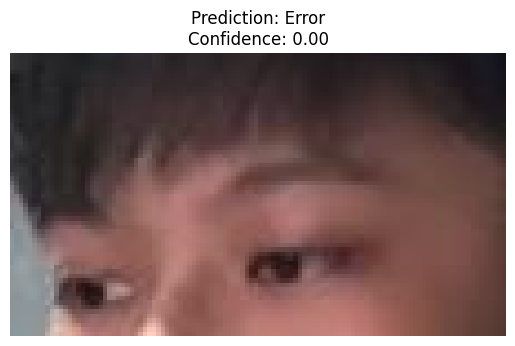

In [39]:
import os
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from scipy.spatial.distance import cosine
from PIL import Image
import matplotlib.pyplot as plt

# Configuration
TEST_PATH = "/content/drive/MyDrive/Face_Dataset/processed_dataset/val"
MODELS_PATH = {
    "top": "/content/drive/MyDrive/Face_Dataset/mobilefacenet_v2_top.keras",
    "mid": "/content/drive/MyDrive/Face_Dataset/mobilefacenet_v2_mid.keras",
    "bottom": "/content/drive/MyDrive/Face_Dataset/mobilefacenet_v2_bottom.keras"
}
THRESHOLD = 0.6  # Similarity threshold for positive match

def load_models():
    """Load all three partition models"""
    models = {}
    for name, path in MODELS_PATH.items():
        models[name] = tf.keras.models.load_model(path)
    return models

def build_gallery(models):
    """Create gallery of known faces from training data"""
    gallery = {}
    for person in os.listdir(os.path.join(TEST_PATH, "top")):
        if person.endswith('.ipynb_checkpoints'):
            continue
        embeddings = []

        # Get one image per partition
        for part in ["top", "mid", "bottom"]:
            dir_path = os.path.join(TEST_PATH, part, person)
            files = os.listdir(dir_path)

            img_path = os.path.join(dir_path, files[0])
            img = Image.open(img_path).convert('RGB')
            # img = np.array(img.resize((112, 112))) / 255.0  # Normalize
            img = np.array(img) / 255.0  # Normalize

            # Get embedding
            embedding = models[part].predict(np.expand_dims(img, axis=0))[0]
            embeddings.append(embedding)

        # Fuse embeddings
        fused_embedding = np.concatenate(embeddings)
        gallery[person] = fused_embedding / np.linalg.norm(fused_embedding)  # Normalize

    return gallery

def test_single_image(image_path, embedding_models, gallery):
    try:
        parts = image_path.split('/')
        partition = parts[-3]

        img = Image.open(image_path).convert('RGB')
        img = np.array(img.resize((112, 64 if partition != 'mid' else 56))) / 255.0

        # Get 512D embedding
        embedding = embedding_models[partition].predict(np.expand_dims(img, axis=0))[0]

        # Verify embedding
        assert embedding.shape == (512,), f"Bad embedding shape: {embedding.shape}"

        best_match = None
        best_score = -1

        for name, gallery_emb in gallery.items():
            # Get relevant partition's embedding
            start_idx = {'top': 0, 'mid': 512, 'bottom': 1024}[partition]
            gallery_part = gallery_emb[start_idx:start_idx+512]

            similarity = 1 - cosine(embedding, gallery_part)
            if similarity > best_score:
                best_score = similarity
                best_match = name

        return best_match if best_score > THRESHOLD else "Unknown", best_score

    except Exception as e:
        print(f"Error processing {image_path}: {str(e)}")
        return "Error", 0.0

def evaluate_test_set(models, gallery):
    """Full evaluation on test set"""
    y_true = []
    y_pred = []

    for partition in ['top', 'mid', 'bottom']:
        partition_path = os.path.join(TEST_PATH, partition)
        for person in os.listdir(partition_path):
            person_path = os.path.join(partition_path, person)
            for img_file in os.listdir(person_path):
                img_path = os.path.join(person_path, img_file)

                # Test the image
                pred, score = test_single_image(img_path, models, gallery)
                y_true.append(person)
                y_pred.append(pred)

                print(f"True: {person} | Pred: {pred} | Score: {score:.2f}")

    # Metrics
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

# Main execution
if __name__ == "__main__":
    # 1. Load models
    models = load_models()

    # 2. Build gallery
    gallery = build_gallery(models)

    # 3. Evaluate
    evaluate_test_set(models, gallery)

    # 4. Test single image (example)
    test_img = "/content/drive/MyDrive/Face_Dataset/processed_dataset/val/top/kyle/kyle_113.jpg"
    match, score = test_single_image(test_img, models, gallery)
    print(f"\nTest Image Result: {match} (confidence: {score:.2f})")

    # Visualize
    img = Image.open(test_img)
    plt.imshow(img)
    plt.title(f"Prediction: {match}\nConfidence: {score:.2f}")
    plt.axis('off')
    plt.show()

## Test Model

In [ ]:
# Setup and Configuration
import os
import numpy as np
import tensorflow as tf
from PIL import Image
from mtcnn.mtcnn import MTCNN
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

# --- Configuration ---
MODELS_PATH = {
    "top": "/content/drive/MyDrive/Face_Dataset/mobilefacenet_model_top.keras",
    "mid": "/content/drive/MyDrive/Face_Dataset/mobilefacenet_model_mid.keras",
    "bottom": "/content/drive/MyDrive/Face_Dataset/mobilefacenet_model_bottom.keras"
}


GALLERY_SOURCE_PATH = "/content/drive/MyDrive/Face_Dataset/extracted_frames"
PROCESSED_TRAIN_PATH = "/content/drive/MyDrive/Face_Dataset/processed_dataset/train"


# These must match the sizes used during training
TARGET_SIZES = {
    "top": (64, 112),    # Height x Width
    "mid": (56, 112),
    "bottom": (64, 112)
}

print("Setup complete.")

TensorFlow Version: 2.18.0
Setup complete.


In [ ]:
# Load Models and Detector

# --- 1. Load the Trained Models ---
print("Loading trained models... (This may take a moment)")
models = {}

models = {}
for name, path in MODELS_PATH.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Model file not found: {path}")

    # Load the full model
    full_model = tf.keras.models.load_model(path, compile=False)

    # Create embedding model (outputs second-to-last layer)
    embedding_model = tf.keras.Model(
        inputs=full_model.input,
        outputs=full_model.layers[-2].output,
        name=f"{name}_embedding"
    )
    models[name] = embedding_model
print("All models loaded successfully.")

# --- Initialize the face detector ---
print("\nInitializing MTCNN face detector...")
detector = MTCNN()
print("MTCNN detector ready.")


Loading trained models... (This may take a moment)
All models loaded successfully.

Initializing MTCNN face detector...
MTCNN detector ready.


In [ ]:
def evaluate_on_partitioned_val(val_path, models, gallery):
    """Evaluate on your pre-partitioned validation set"""
    correct = 0
    total = 0

    # Get all person names from gallery
    known_persons = list(gallery.keys())

    # For each person in validation set
    for person_name in os.listdir(os.path.join(val_path, "top")):
        if person_name not in known_persons:
            continue

        # Get all images for this person across partitions
        top_images = os.listdir(os.path.join(val_path, "top", person_name))
        mid_images = os.listdir(os.path.join(val_path, "mid", person_name))
        bottom_images = os.listdir(os.path.join(val_path, "bottom", person_name))

        # Find common base names across partitions
        common_images = set(top_images) & set(mid_images) & set(bottom_images)

        for img_base in common_images:
            # Build full paths to each partition
            img_paths = {
                "top": os.path.join(val_path, "top", person_name, img_base),
                "mid": os.path.join(val_path, "mid", person_name, img_base),
                "bottom": os.path.join(val_path, "bottom", person_name, img_base)
            }

            # Load and preprocess each partition
            partitions = {}
            for part_name, path in img_paths.items():
                img = Image.open(path)
                img_array = np.array(img).astype('float32')
                img_array = (img_array - 127.5) / 128.0  # Normalize
                partitions[part_name] = np.expand_dims(img_array, axis=0)

            # Get fused embedding
            fused_emb = np.concatenate([
                models["top"].predict(partitions["top"], verbose=0),
                models["mid"].predict(partitions["mid"], verbose=0),
                models["bottom"].predict(partitions["bottom"], verbose=0)
            ], axis=1)

            # Normalize
            fused_emb /= np.linalg.norm(fused_emb)

            # Compare with gallery
            best_match = None
            best_score = -1
            for name, emb in gallery.items():
                score = 1 - cosine(fused_emb.flatten(), emb.flatten())
                if score > best_score:
                    best_score = score
                    best_match = name

            if best_match == person_name:
                correct += 1
            total += 1

            print(f"{person_name}/{img_base}: {best_match} ({best_score:.2f})")

    accuracy = correct / total if total > 0 else 0
    print(f"\nFinal Accuracy: {accuracy:.2%}")
    return accuracy

In [ ]:
def build_gallery_from_partitioned(train_path, models):
    gallery = {}

    # Get all person names from any partition (assuming same across partitions)
    person_names = os.listdir(os.path.join(train_path, "top"))

    for person_name in person_names:
        # Get all images for this person across partitions
        top_images = os.listdir(os.path.join(train_path, "top", person_name))
        mid_images = os.listdir(os.path.join(train_path, "mid", person_name))
        bottom_images = os.listdir(os.path.join(train_path, "bottom", person_name))

        common_images = set(top_images) & set(mid_images) & set(bottom_images)
        embeddings = []

        for img_base in common_images:
            # Process each partition
            partitions = {}
            for part_name in ["top", "mid", "bottom"]:
                path = os.path.join(train_path, part_name, person_name, img_base)
                img = Image.open(path)
                img_array = np.array(img).astype('float32')
                img_array = (img_array - 127.5) / 128.0
                partitions[part_name] = np.expand_dims(img_array, axis=0)

            # Get fused embedding
            fused_emb = np.concatenate([
                models["top"].predict(partitions["top"], verbose=0),
                models["mid"].predict(partitions["mid"], verbose=0),
                models["bottom"].predict(partitions["bottom"], verbose=0)
            ], axis=1)

            fused_emb /= np.linalg.norm(fused_emb)
            embeddings.append(fused_emb)

        if embeddings:
            gallery[person_name] = np.mean(embeddings, axis=0)
            print(f"Added {person_name} with {len(embeddings)} embeddings")

    return gallery

In [ ]:
# Paths
TRAIN_PATH = "/content/drive/MyDrive/Face_Dataset/processed_dataset/train"
VAL_PATH = "/content/drive/MyDrive/Face_Dataset/processed_dataset/val"

# 1. Build gallery from training partitions
gallery = build_gallery_from_partitioned(TRAIN_PATH, models)

# 2. Evaluate on validation partitions
accuracy = evaluate_on_partitioned_val(VAL_PATH, models, gallery)

Added Tom Cruise with 40 embeddings
Added Zac Efron with 40 embeddings
Added kyle with 40 embeddings
Tom Cruise vs Zac Efron: 1.0000
Tom Cruise vs kyle: 1.0000
Zac Efron vs kyle: 1.0000
Tom Cruise/Tom Cruise_39.jpg: Tom Cruise (1.00)
Tom Cruise/Tom Cruise_48.jpg: Tom Cruise (1.00)
Tom Cruise/Tom Cruise_40.jpg: Tom Cruise (1.00)
Tom Cruise/Tom Cruise_51.jpg: Tom Cruise (1.00)
Tom Cruise/Tom Cruise_5.jpg: Tom Cruise (1.00)
Tom Cruise/Tom Cruise_22.jpg: Tom Cruise (1.00)
Tom Cruise/Tom Cruise_18.jpg: Tom Cruise (1.00)
Tom Cruise/Tom Cruise_14.jpg: Tom Cruise (1.00)
Tom Cruise/Tom Cruise_49.jpg: Tom Cruise (1.00)
Tom Cruise/Tom Cruise_10.jpg: Tom Cruise (1.00)
Zac Efron/Zac Efron_71.jpg: Tom Cruise (1.00)
Zac Efron/Zac Efron_83.jpg: Tom Cruise (1.00)
Zac Efron/Zac Efron_19.jpg: Tom Cruise (1.00)
Zac Efron/Zac Efron_56.jpg: Tom Cruise (1.00)
Zac Efron/Zac Efron_47.jpg: Tom Cruise (1.00)
Zac Efron/Zac Efron_67.jpg: Tom Cruise (1.00)
Zac Efron/Zac Efron_30.jpg: Tom Cruise (1.00)
Zac Efron/Zac

## Archives

In [ ]:
def process_and_save_partitions(image_path, output_folder="processed_data"):
    """
    Main function to detect, partition, resize, and augment a face from an image.
    """
    # --- Setup ---
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        os.makedirs(os.path.join(output_folder, "resized"))
        os.makedirs(os.path.join(output_folder, "augmented"))

    try:
        image = Image.open(image_path).convert('RGB')
    except FileNotFoundError:
        print(f"Error: Image not found at {image_path}")
        return

    image_np = np.asarray(image)
    detector = MTCNN()
    faces = detector.detect_faces(image_np)

    if not faces:
        print("No face detected.")
        return

    # --- Detection and Cropping ---
    face_data = faces[0]
    x, y, width, height = face_data['box']
    landmarks = face_data['keypoints']
    cropped_face = image.crop((x, y, x + width, y + height))

    # --- Landmark-Based Partitioning ---
    left_eye_rel = (landmarks['left_eye'][0] - x, landmarks['left_eye'][1] - y)
    right_eye_rel = (landmarks['right_eye'][0] - x, landmarks['right_eye'][1] - y)
    mouth_left_rel = (landmarks['mouth_left'][0] - x, landmarks['mouth_left'][1] - y)
    mouth_right_rel = (landmarks['mouth_right'][0] - x, landmarks['mouth_right'][1] - y)

    eye_level_y = (left_eye_rel[1] + right_eye_rel[1]) / 2
    mouth_level_y = (mouth_left_rel[1] + mouth_right_rel[1]) / 2

    cut_line_1 = int(eye_level_y + height * 0.10)
    cut_line_2 = int(mouth_level_y - height * 0.10)

    cut_line_1 = max(0, min(cut_line_1, height))
    cut_line_2 = max(0, min(cut_line_2, height))

    if cut_line_1 >= cut_line_2:
        cut_line_1, cut_line_2 = int(height * 0.40), int(height * 0.65)

    face_width = cropped_face.width
    partitions = {
        "top": cropped_face.crop((0, 0, face_width, cut_line_1)),
        "mid": cropped_face.crop((0, cut_line_1, face_width, cut_line_2)),
        "bottom": cropped_face.crop((0, cut_line_2, face_width, height))
    }

    print("Partitions created successfully.")

    # --- Define Target Sizes for Each Partition ---
    # These sizes are what your models will expect as input.
    target_sizes = {
        "top": (112, 64),  # Width x Height
        "mid": (112, 56),
        "bottom": (112, 64)
    }

    # --- Process Each Partition ---
    base_filename = os.path.splitext(os.path.basename(image_path))[0]
    resized_partitions = {}

    for name, part_image in partitions.items():
        # --- 1. Resizing ---
        target_size = target_sizes[name]
        # Using LANCZOS for high-quality downsampling
        resized_image = part_image.resize(target_size, Image.Resampling.LANCZOS)
        resized_partitions[name] = resized_image # Store for visualization

        # Save the resized image
        resized_image.save(os.path.join(output_folder, "resized", f"{base_filename}_{name}_resized.jpg"))

        # --- 2. Simple Augmentation (Horizontal Flip) ---
        # Augment the RESIZED image
        augmented_image = augment_image(resized_image)
        augmented_image.save(os.path.join(output_folder, "augmented", f"{base_filename}_{name}_augmented_flip.jpg"))

    print(f"\nSaved resized and augmented partitions to the '{output_folder}' folder.")

    # --- Visualization (Great for Jupyter!) ---
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.suptitle('Original, Resized, and Augmented (Flipped) Partitions', fontsize=16)

    # Plotting Top Partition
    axes[0, 0].set_title("Original Top")
    axes[0, 0].imshow(partitions['top'])
    axes[0, 1].set_title(f"Resized Top\n{target_sizes['top'][0]}x{target_sizes['top'][1]}")
    axes[0, 1].imshow(resized_partitions['top'])
    axes[0, 2].set_title("Augmented (Flipped)")
    axes[0, 2].imshow(Image.open(os.path.join(output_folder, "augmented", f"{base_filename}_top_augmented_flip.jpg")))

    # Plotting Mid Partition
    axes[1, 0].set_title("Original Mid")
    axes[1, 0].imshow(partitions['mid'])
    axes[1, 1].set_title(f"Resized Mid\n{target_sizes['mid'][0]}x{target_sizes['mid'][1]}")
    axes[1, 1].imshow(resized_partitions['mid'])
    axes[1, 2].set_title("Augmented (Flipped)")
    axes[1, 2].imshow(Image.open(os.path.join(output_folder, "augmented", f"{base_filename}_mid_augmented_flip.jpg")))

    # Plotting Bottom Partition
    axes[2, 0].set_title("Original Bottom")
    axes[2, 0].imshow(partitions['bottom'])
    axes[2, 1].set_title(f"Resized Bottom\n{target_sizes['bottom'][0]}x{target_sizes['bottom'][1]}")
    axes[2, 1].imshow(resized_partitions['bottom'])
    axes[2, 2].set_title("Augmented (Flipped)")
    axes[2, 2].imshow(Image.open(os.path.join(output_folder, "augmented", f"{base_filename}_bottom_augmented_flip.jpg")))

    for ax_row in axes:
        for ax in ax_row:
            ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
def normalize_image(image_pil):
    """
    Normalizes a PIL image by converting it to a NumPy array,
    scaling pixel values to the [0, 1] range, and returning it.
    """
    image_np = np.asarray(image_pil).astype(np.float32)
    # Scale pixel values from [0, 255] to [0, 1]
    normalized_np = image_np / 255.0
    return normalized_np

def augment_image(image_pil):
    """
    Applies a simple horizontal flip augmentation.
    """
    # Convert PIL image to NumPy array for imgaug
    image_np = np.asarray(image_pil)

    # Define a simple augmentation sequence: just a horizontal flip
    seq = iaa.Sequential([
        iaa.Fliplr(1.0), # always flip horizontally for this example
    ])

    # Augment the image
    augmented_np = seq(image=image_np)

    # Convert back to PIL Image
    augmented_pil = Image.fromarray(augmented_np)

    return augmented_pil

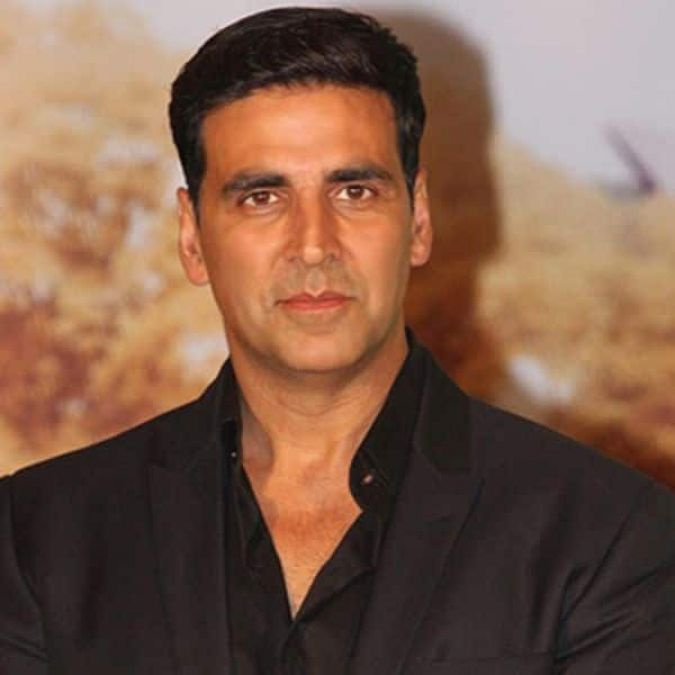

In [ ]:
from PIL import Image

input_image_path = "test_image.jpg"
image = Image.open(input_image_path)

# Display the image (optional)
image


Partitions created successfully.

Saved resized and augmented partitions to the 'processed_data' folder.


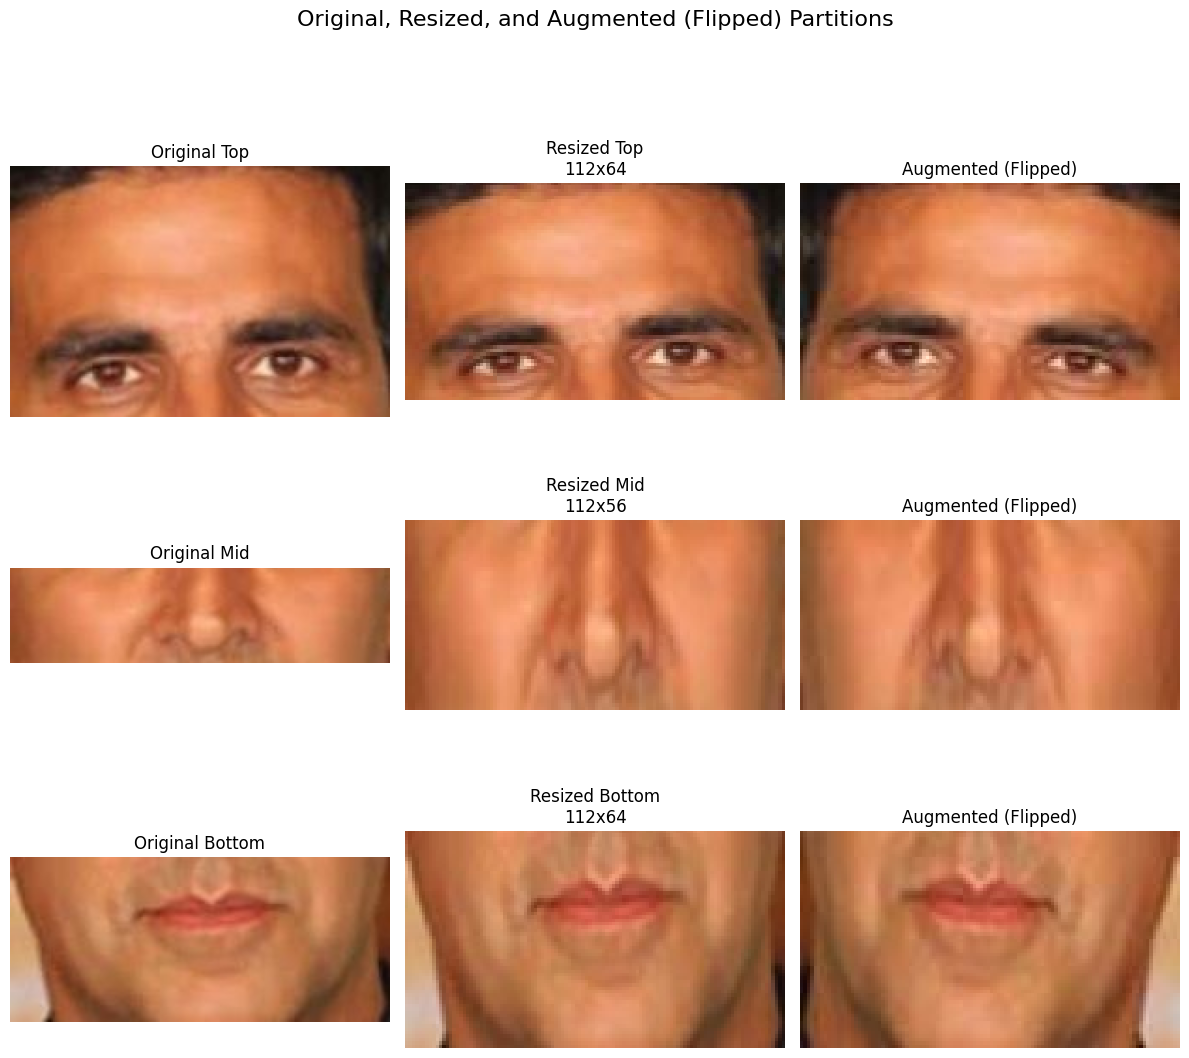

In [ ]:
process_and_save_partitions(input_image_path)

In [ ]:
# Define a sample image path
sample_image_path = "/content/drive/MyDrive/Face_Dataset/extracted_frames/kyle/kyle_1.jpg" # Replace with your image path

# Ensure necessary libraries are imported
from PIL import Image
import numpy as np
from mtcnn.mtcnn import MTCNN
import matplotlib.pyplot as plt
import os

# Re-define or ensure preprocess_and_partition and detector are available
# (Assuming preprocess_and_partition and detector are defined in previous cells)

# Initialize the face detector if not already done
if 'detector' not in locals():
    detector = MTCNN()
    print("MTCNN detector initialized.")

# Define the target sizes used during preprocessing
# These should match the TARGET_SIZES in your data processing cell
TARGET_SIZES = {
    "top": (64, 112),    # Height x Width
    "mid": (56, 112),
    "bottom": (64, 112)
}

# Get the processed partitions
partitions = preprocess_and_partition(sample_image_path)

if partitions:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Face Partitions for {os.path.basename(sample_image_path)}', fontsize=16)

    axes[0].imshow(partitions['top'][0]) # Access the image from the batch dimension
    axes[0].set_title("Top Partition")
    axes[0].axis('off')

    axes[1].imshow(partitions['mid'][0]) # Access the image from the batch dimension
    axes[1].set_title("Mid Partition")
    axes[1].axis('off')

    axes[2].imshow(partitions['bottom'][0]) # Access the image from the batch dimension
    axes[2].set_title("Bottom Partition")
    axes[2].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print(f"Could not process {sample_image_path} to show partitions.")

In [ ]:
!pip install onnxruntime